In [15]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from data.simulations import (
    c1_chain,
    c2_fork,
    c3_unobserved_feature_confounder,
    c4_observed_feature_confounder,
    c5_collider,
    c6_unobserved_prediction_confounder,
)
from shapley_values.causal_shap import Explainer, ShapleyValuesType
from shapley_values.utils import get_baseline
import numpy as np
import xgboost
import shap

In [26]:
N_RUNS = 10
N_SAMPLES = 5000


def mc_run(generator, sample, feature_names, n_runs = N_RUNS, n_samples = N_SAMPLES, **shapley_kwargs):
    """Run N_RUNS MC iterations; return mean / std of Shapley values."""
    all_phis = []
    last_X, last_model = None, None
    for seed in range(n_runs):
        X, y = generator(num_samples=n_samples, seed=seed)
        model = xgboost.XGBRegressor(random_state=seed)
        model.fit(X, y)
        X = np.vstack([X, sample])
        explainer = Explainer(X=X, model=model, is_classification=False,
                              rounding_precision=1, feature_names=feature_names)
        phis = explainer.compute_shapley_values(sample, **shapley_kwargs)
        all_phis.append(phis)
        last_X, last_model = X, model
    arr = np.array(all_phis)
    return arr.mean(axis=0), arr.std(axis=0), last_X, last_model

# Conditional Shapley on canonical structures (C1–C6)

# C1

Baseline Value (E[f(X)]):  1.005891
Predicted Value (f(x))  [1.9949361]
Shapley Values + (E[f(X)]):  1.995
Baseline Value (E[f(X)]):  0.9891887
Predicted Value (f(x))  [2.0017045]
Shapley Values + (E[f(X)]):  2.002
Baseline Value (E[f(X)]):  1.0119014
Predicted Value (f(x))  [1.9963425]
Shapley Values + (E[f(X)]):  1.996
Baseline Value (E[f(X)]):  1.0003343
Predicted Value (f(x))  [1.9999193]
Shapley Values + (E[f(X)]):  2.0
Baseline Value (E[f(X)]):  1.0171686
Predicted Value (f(x))  [1.9980134]
Shapley Values + (E[f(X)]):  1.998
Baseline Value (E[f(X)]):  1.0228858
Predicted Value (f(x))  [2.0018432]
Shapley Values + (E[f(X)]):  2.002
Baseline Value (E[f(X)]):  1.002706
Predicted Value (f(x))  [1.9927622]
Shapley Values + (E[f(X)]):  1.993
Baseline Value (E[f(X)]):  0.98746425
Predicted Value (f(x))  [1.9984394]
Shapley Values + (E[f(X)]):  1.998
Baseline Value (E[f(X)]):  0.9905701
Predicted Value (f(x))  [2.003871]
Shapley Values + (E[f(X)]):  2.004
Baseline Value (E[f(X)]):  1.005

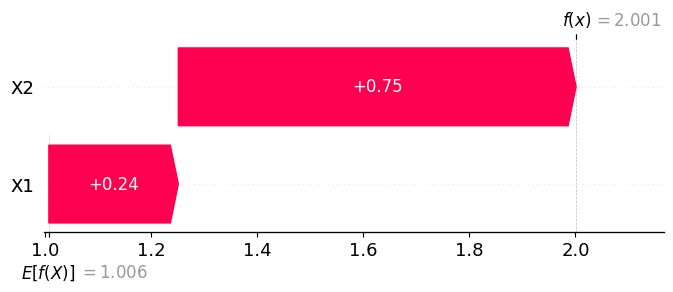

In [17]:
sample = np.array([1, 2])
feature_names = ["X1", "X2"]
mean_phis, std_phis, X, model = mc_run(c1_chain, sample, feature_names, type=ShapleyValuesType.CONDITIONAL)

print(f"Mean: {mean_phis.round(3)}")
print(f"Std : {std_phis.round(3)}")

explanation = shap.Explanation(values=mean_phis, feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)

# C2

Baseline Value (E[f(X)]):  0.498036
Predicted Value (f(x))  [1.5081788]
Shapley Values + (E[f(X)]):  1.508
Baseline Value (E[f(X)]):  0.4928535
Predicted Value (f(x))  [1.4920644]
Shapley Values + (E[f(X)]):  1.492
Baseline Value (E[f(X)]):  0.50071305
Predicted Value (f(x))  [1.5133582]
Shapley Values + (E[f(X)]):  1.513
Baseline Value (E[f(X)]):  0.50249803
Predicted Value (f(x))  [1.5092645]
Shapley Values + (E[f(X)]):  1.509
Baseline Value (E[f(X)]):  0.5083349
Predicted Value (f(x))  [1.5231338]
Shapley Values + (E[f(X)]):  1.523
Baseline Value (E[f(X)]):  0.5150998
Predicted Value (f(x))  [1.4919707]
Shapley Values + (E[f(X)]):  1.492
Baseline Value (E[f(X)]):  0.50939023
Predicted Value (f(x))  [1.4901049]
Shapley Values + (E[f(X)]):  1.49
Baseline Value (E[f(X)]):  0.4905622
Predicted Value (f(x))  [1.5104138]
Shapley Values + (E[f(X)]):  1.51
Baseline Value (E[f(X)]):  0.49805146
Predicted Value (f(x))  [1.4934945]
Shapley Values + (E[f(X)]):  1.493
Baseline Value (E[f(X)]):  

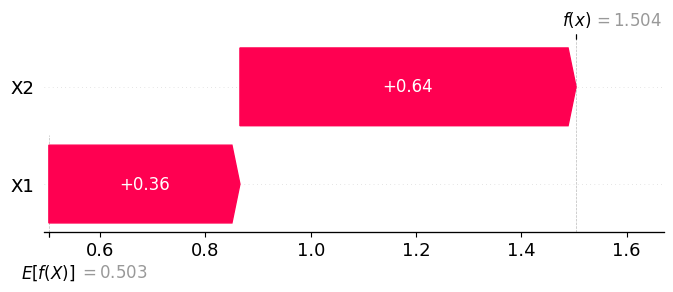

In [18]:
sample = np.array([2.5, 1.5])
feature_names = ["X1", "X2"]
mean_phis, std_phis, X, model = mc_run(c2_fork, sample, feature_names, type=ShapleyValuesType.CONDITIONAL)

print(f"Mean: {mean_phis.round(3)}")
print(f"Std : {std_phis.round(3)}")

explanation = shap.Explanation(values=mean_phis, feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)

# C3

Baseline Value (E[f(X)]):  1.0021989
Predicted Value (f(x))  [2.0006478]
Shapley Values + (E[f(X)]):  2.001
Baseline Value (E[f(X)]):  0.9841185
Predicted Value (f(x))  [2.00482]
Shapley Values + (E[f(X)]):  2.005
Baseline Value (E[f(X)]):  1.0076735
Predicted Value (f(x))  [1.9918677]
Shapley Values + (E[f(X)]):  1.992
Baseline Value (E[f(X)]):  1.0097396
Predicted Value (f(x))  [2.0080862]
Shapley Values + (E[f(X)]):  2.008
Baseline Value (E[f(X)]):  1.0099643
Predicted Value (f(x))  [2.0106134]
Shapley Values + (E[f(X)]):  2.011
Baseline Value (E[f(X)]):  1.0137768
Predicted Value (f(x))  [2.0000153]
Shapley Values + (E[f(X)]):  2.0
Baseline Value (E[f(X)]):  1.0077248
Predicted Value (f(x))  [2.0020533]
Shapley Values + (E[f(X)]):  2.002
Baseline Value (E[f(X)]):  0.99005806
Predicted Value (f(x))  [2.0001185]
Shapley Values + (E[f(X)]):  2.0
Baseline Value (E[f(X)]):  1.0106065
Predicted Value (f(x))  [2.0005078]
Shapley Values + (E[f(X)]):  2.001
Baseline Value (E[f(X)]):  0.9913

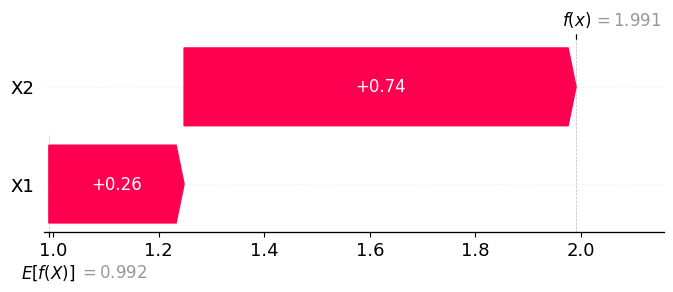

In [19]:
sample = np.array([2, 2])
feature_names = ["X1", "X2"]
mean_phis, std_phis, X, model = mc_run(c3_unobserved_feature_confounder, sample, feature_names, type=ShapleyValuesType.CONDITIONAL)

print(f"Mean: {mean_phis.round(3)}")
print(f"Std : {std_phis.round(3)}")

explanation = shap.Explanation(values=mean_phis, feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)

# C4

Baseline Value (E[f(X)]):  1.002029
Predicted Value (f(x))  [1.9999921]
Shapley Values + (E[f(X)]):  2.0
Baseline Value (E[f(X)]):  0.9843742
Predicted Value (f(x))  [2.006982]
Shapley Values + (E[f(X)]):  2.007
Baseline Value (E[f(X)]):  1.008416
Predicted Value (f(x))  [1.985951]
Shapley Values + (E[f(X)]):  1.986
Baseline Value (E[f(X)]):  1.0098202
Predicted Value (f(x))  [2.0137312]
Shapley Values + (E[f(X)]):  2.014
Baseline Value (E[f(X)]):  1.0098051
Predicted Value (f(x))  [2.0100946]
Shapley Values + (E[f(X)]):  2.01
Baseline Value (E[f(X)]):  1.0136942
Predicted Value (f(x))  [1.9998956]
Shapley Values + (E[f(X)]):  2.0
Baseline Value (E[f(X)]):  1.0076476
Predicted Value (f(x))  [1.9961351]
Shapley Values + (E[f(X)]):  1.996
Baseline Value (E[f(X)]):  0.98998404
Predicted Value (f(x))  [2.000845]
Shapley Values + (E[f(X)]):  2.001
Baseline Value (E[f(X)]):  1.0106694
Predicted Value (f(x))  [1.995964]
Shapley Values + (E[f(X)]):  1.996
Baseline Value (E[f(X)]):  0.99155337


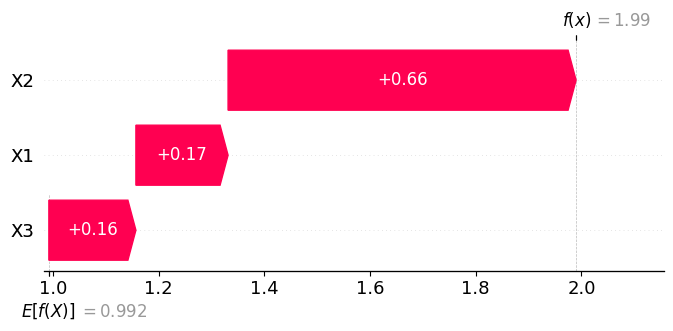

In [20]:
sample = np.array([2, 2, 1])
feature_names = ["X1", "X2", "X3"]
mean_phis, std_phis, X, model = mc_run(c4_observed_feature_confounder, sample, feature_names, type=ShapleyValuesType.CONDITIONAL)

print(f"Mean: {mean_phis.round(3)}")
print(f"Std : {std_phis.round(3)}")

explanation = shap.Explanation(values=mean_phis, feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)

# C5

Baseline Value (E[f(X)]):  2.0221994
Predicted Value (f(x))  [2.9960809]
Shapley Values + (E[f(X)]):  2.996
Baseline Value (E[f(X)]):  1.9763196
Predicted Value (f(x))  [3.0076745]
Shapley Values + (E[f(X)]):  3.008
Baseline Value (E[f(X)]):  2.0336752
Predicted Value (f(x))  [3.0125277]
Shapley Values + (E[f(X)]):  3.013
Baseline Value (E[f(X)]):  2.0039818
Predicted Value (f(x))  [3.0137045]
Shapley Values + (E[f(X)]):  3.014
Baseline Value (E[f(X)]):  2.0281873
Predicted Value (f(x))  [2.9863563]
Shapley Values + (E[f(X)]):  2.986
Baseline Value (E[f(X)]):  2.0227842
Predicted Value (f(x))  [2.9908798]
Shapley Values + (E[f(X)]):  2.991
Baseline Value (E[f(X)]):  1.9902277
Predicted Value (f(x))  [3.0078702]
Shapley Values + (E[f(X)]):  3.008
Baseline Value (E[f(X)]):  1.984144
Predicted Value (f(x))  [2.9901397]
Shapley Values + (E[f(X)]):  2.99
Baseline Value (E[f(X)]):  1.9933894
Predicted Value (f(x))  [3.0165346]
Shapley Values + (E[f(X)]):  3.017
Baseline Value (E[f(X)]):  1.9

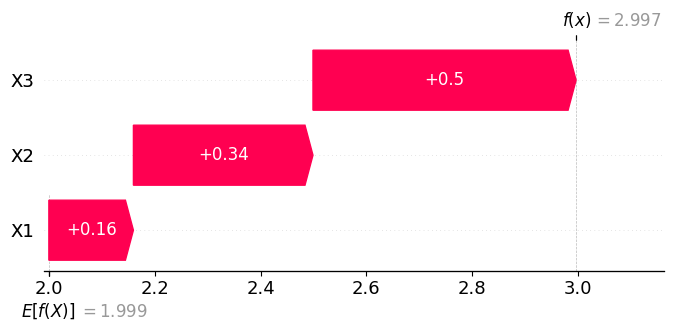

In [21]:
sample = np.array([0.75, 0.75, 2.25])
feature_names = ["X1", "X2", "X3"]
mean_phis, std_phis, X, model = mc_run(c5_collider, sample, feature_names, type=ShapleyValuesType.CONDITIONAL)

print(f"Mean: {mean_phis.round(3)}")
print(f"Std : {std_phis.round(3)}")

explanation = shap.Explanation(values=mean_phis, feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)

# C6

Baseline Value (E[f(X)]):  1.0161127
Predicted Value (f(x))  [2.204472]
Shapley Values + (E[f(X)]):  2.204
Baseline Value (E[f(X)]):  0.9899172
Predicted Value (f(x))  [1.9284266]
Shapley Values + (E[f(X)]):  1.928
Baseline Value (E[f(X)]):  1.0030233
Predicted Value (f(x))  [1.9275244]
Shapley Values + (E[f(X)]):  1.928
Baseline Value (E[f(X)]):  0.9899314
Predicted Value (f(x))  [2.0031025]
Shapley Values + (E[f(X)]):  2.003
Baseline Value (E[f(X)]):  0.99960035
Predicted Value (f(x))  [1.818493]
Shapley Values + (E[f(X)]):  1.818
Baseline Value (E[f(X)]):  0.99349946
Predicted Value (f(x))  [2.1536238]
Shapley Values + (E[f(X)]):  2.154
Baseline Value (E[f(X)]):  0.9838681
Predicted Value (f(x))  [1.8803611]
Shapley Values + (E[f(X)]):  1.88
Baseline Value (E[f(X)]):  0.9935946
Predicted Value (f(x))  [2.1511905]
Shapley Values + (E[f(X)]):  2.151
Baseline Value (E[f(X)]):  1.002356
Predicted Value (f(x))  [1.8806953]
Shapley Values + (E[f(X)]):  1.881
Baseline Value (E[f(X)]):  1.0

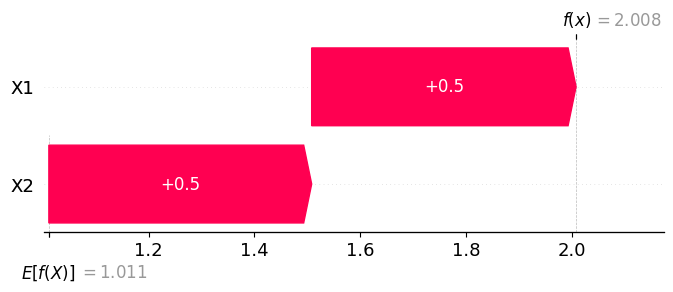

In [27]:
sample = np.array([2, 1])
feature_names = ["X1", "X2"]
mean_phis, std_phis, X, model = mc_run(c6_unobserved_prediction_confounder, sample, feature_names, type=ShapleyValuesType.CONDITIONAL, n_samples=10000)

print(f"Mean: {mean_phis.round(3)}")
print(f"Std : {std_phis.round(3)}")

explanation = shap.Explanation(values=mean_phis, feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)